In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ucitavanje i prikaz videa


video = cv2.VideoCapture("C:\\keyframes\\talasi.mp4")

while video.isOpened():
    ret, frame = video.read()
    
    if not ret or frame is None:
        print('gotov video')
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    vis, sir = gray.shape
    print(f"vis: {vis}, sir {sir}")
    
    resized_frame = cv2.resize(gray, (960, 540))
    cv2.imshow('talasi', resized_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
video.release()
cv2.destroyAllWindows()


In [ ]:
#trajanje videa

import cv2
import datetime

# 1. Load the video file
video_path = ".\\talasi.mp4"
cap = cv2.VideoCapture(video_path)

# 2. Check if the video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
else:
    # 3. Retrieve total frames and FPS properties
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # 4. Calculate total duration in seconds
    if fps > 0:
        duration_seconds = total_frames / fps
        
        # 5. Format into a human-readable string (HH:MM:SS)
        duration_formatted = str(datetime.timedelta(seconds=int(duration_seconds)))
        
        print(f"Total Frames: {total_frames}")
        print(f"FPS: {fps}")
        print(f"Duration (Seconds): {duration_seconds:.2f} seconds")
        print(f"Duration (HH:MM:SS): {duration_formatted}")
    else:
        print("Error: FPS is zero. Cannot calculate duration.")

# 6. Free up resources
cap.release()


Total Frames: 723.0
FPS: 24.0
Duration (Seconds): 30.12 seconds
Duration (HH:MM:SS): 0:00:30


merenje promene pixela izmedju frejmova

In [ ]:
video = cv2.VideoCapture(".\\surfer_talasi.mp4")

ret, prev_frame = video.read() #uzima sledeci frejm, ret je true/false, prev_frame je slika
if not ret:
    exit()
 
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
prev_gray = cv2.GaussianBlur(prev_gray, (21, 21), 0)

threshold = 500.5
fr = 0
while video.isOpened():
    ret, frame = video.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (21,21), 0)
    
    resized_frame = cv2.resize(gray, (960, 540))
    cv2.imshow('talasi', resized_frame)
        
    #racunamo abs diff na trenutnom i prethodnom frameu
    
    delta_frame = cv2.absdiff(prev_gray, gray)
    thresh = cv2.threshold(delta_frame, 25, 255, cv2.THRESH_BINARY)[1]
    
    #racunamo koliko pixela se promenilo
    non_zero_count = np.count_nonzero(thresh)
    
    if non_zero_count > threshold:
        scene_state = 'Dynamic'
    else:
        scene_state = 'Static'
        
    print(f"frame: {fr} scene is: {scene_state} (changed pixels: {non_zero_count})")
    
    prev_gray = gray
    fr += 1
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    
video.release()
cv2.destroyAllWindows()

frejm 290, 70.15961178626543
581931884, 70.15961178626543
frejm 549, 43.1776481722608
358132685, 43.1776481722608
[(290, np.float64(70.15961178626543)), (549, np.float64(43.1776481722608))]


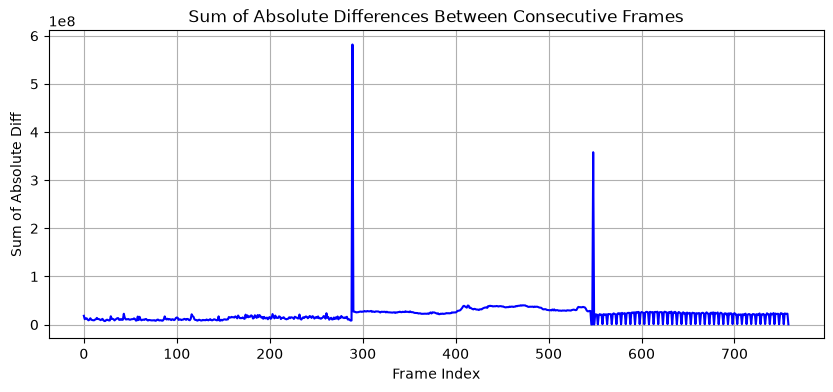

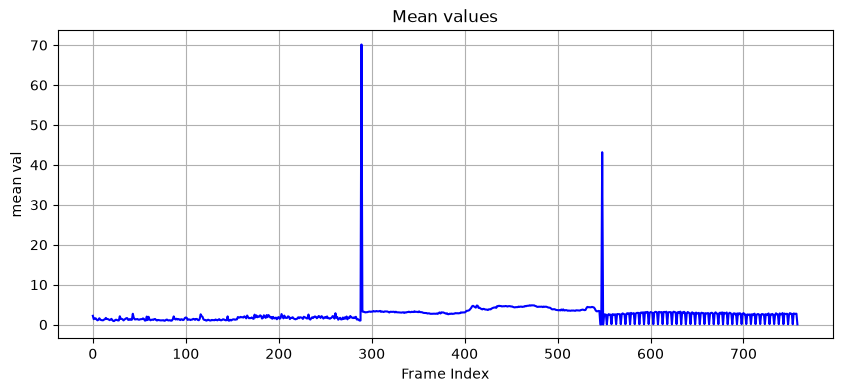

In [ ]:
from functions import scene_detection_SAD

changes, sad_val, mean_val = scene_detection_SAD(".\\vodopad_surf_talasi.mp4", threshold=15)
print(changes)

plt.figure(figsize = (10, 4))
plt.plot(sad_val, color = 'blue')
plt.title('Sum of Absolute Differences Between Consecutive Frames')
plt.xlabel('Frame Index')
plt.ylabel('Sum of Absolute Diff')
plt.grid(True)
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(mean_val, color='blue')
plt.title('Mean values')
plt.xlabel('Frame Index')
plt.ylabel('mean val')
plt.grid(True)
plt.show()

adaptive threshold

scene changed at frame: 150, vreme: 5.0
scene changed at frame: 270, vreme: 9.0
scene changed at frame: 394, vreme: 13.133333333333333
scene changed at frame: 567, vreme: 18.9


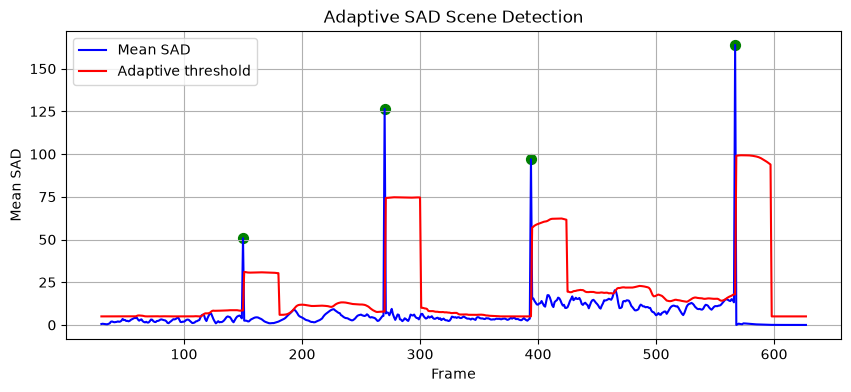

In [ ]:
from functions import adaptive_threshold1

scene_changes, all_mean_sads, thresholds, frame_indices = adaptive_threshold1(
    ".\\proba2.mp4", window_size = 30, threshold_factor = 3.0, min_sad = 5.0)

plt.figure(figsize=(10, a))

plt.plot(frame_indices, all_mean_sads, color = "blue", label = "Mean SAD")
plt.plot(frame_indices, thresholds, color = "red", label = "Adaptive threshold")

# Obeleži detektovane scene change-ove
for frame, sad in scene_changes:
    plt.scatter(frame, sad, color = "green", s = 50)

plt.title("Adaptive SAD Scene Detection")
plt.xlabel("Frame")
plt.ylabel("Mean SAD")

plt.legend()
plt.grid(True)
plt.show()



In [ ]:
from functions import adaptive_histogram

scene_changes, all_mean_sads, thresholds, frame_indices = adaptive_threshold1(
    "C:\\keyframes\\proba2.mp4", window_size=30, threshold_factor=3.0, min_hist_diff=0.05,)

plt.figure(figsize=(10, 4))

plt.plot(frame_indices, all_mean_sads, color="blue", label="Mean SAD")
plt.plot(frame_indices, thresholds, color="red", label="Adaptive threshold")

# Obeleži detektovane scene change-ove
for frame, sad in scene_changes:
    plt.scatter(frame, sad, color="green", s=50)

plt.title("Adaptive SAD Scene Detection")
plt.xlabel("Frame")
plt.ylabel("Mean SAD")

plt.legend()
plt.grid(True)
plt.show()



In [4]:
print(scene_changes)

[(153, np.float64(50.18804253472222)), (296, np.float64(51.434796006944445)), (441, np.float64(104.17659722222223)), (587, np.float64(62.0215234375)), (742, np.float64(111.31927517361112)), (852, np.float64(51.403637152777776)), (975, np.float64(69.96346354166667)), (1107, np.float64(40.42781684027778)), (1200, np.float64(41.95606336805555)), (1337, np.float64(61.87599392361111))]


In [5]:
cap = cv2.VideoCapture('C:\keyframes\proba.mp4')

fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Video Metadata FPS: {fps}")

cap.release()

Video Metadata FPS: 30.0


evaluacija na jednom videu

In [ ]:
from functions import evaluatef

scene_changes, all_mean_sads, thresholds, frame_indices = adaptive_threshold1(
    "C:\\keyframes\\proba.mp4", window_size=30, threshold_factor=3.0, min_sad=5.0)

cap = cv2.VideoCapture('C:\\keyframes\\proba.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

detected_times = [frame / fps for frame, threshold in scene_changes]

print("Detektovane promene:")
for frame, time in zip([x[0] for x in scene_changes], detected_times):
    print(f"Frame {frame} -> {time:.2f} s")
    
true_times = [3.0, 6.0, 10.0, 16.0, 20.0, 23.0]

precision, recall, f1 = evaluatef(
    detected_times,
    true_times,
    tolerance=2.0
)

print("\nEvaluacija:")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

scene changed at frame: 116, vreme: 3.8666666666666667
scene changed at frame: 331, vreme: 11.033333333333333
scene changed at frame: 369, vreme: 12.3
scene changed at frame: 495, vreme: 16.5
scene changed at frame: 627, vreme: 20.9
Detektovane promene:
Frame 116 -> 3.87 s
Frame 331 -> 11.03 s
Frame 369 -> 12.30 s
Frame 495 -> 16.50 s
Frame 627 -> 20.90 s

Evaluacija:
Precision: 0.800
Recall:    0.667
F1-score:  0.727


koja kombinacija parametra je najbolja

In [2]:
from functions import adaptive_threshold1
from functions import evaluatef

# ==========================================
# GRID SEARCH
# ==========================================

window_sizes = [15, 30, 45]
threshold_factors = [2.0, 3.0, 4.0]
peak_multipliers = [1.5, 2.0, 2.6, 3.0]

videos = [
    {
        "name": "Video 1",
        "path": "C:\\keyframes\\evaluation\\test1.mp4",
        "true_times": [9, 18]
    },
    {
        "name": "Video 2",
        "path": "C:\\keyframes\\evaluation\\test2.mp4",
        "true_times": [5, 9, 14, 19, 24, 27, 31, 36, 40, 44]
    },
    {
        "name": "Video 3",
        "path": "C:\\keyframes\\evaluation\\test3.mp4",
        "true_times": [4, 9, 13, 18]
    },
    {
        "name": "Video 4",
        "path": "C:\\keyframes\\evaluation\\test4.mp4",
        "true_times": [3, 6, 10, 16, 20, 23]
    },
    {
        "name": "Video 5",
        "path": "C:\\keyframes\\evaluation\\test5.mp4",
        "true_times": [3, 5, 11]
    },
    {
        "name": "Video 6",
        "path": "C:\\keyframes\\evaluation\\test6.mp4",
        "true_times": [5, 10, 15]
    }
]


results = []

total_combinations = (
    len(window_sizes)
    * len(threshold_factors)
    * len(peak_multipliers)
)

combination_number = 0


for window_size in window_sizes:

    for threshold_factor in threshold_factors:

        for peak_multiplier in peak_multipliers:

            combination_number += 1

            print(
                f"\nKombinacija {combination_number}/{total_combinations}: "
                f"window={window_size}, "
                f"factor={threshold_factor}, "
                f"peak={peak_multiplier}"
            )

            video_f1_scores = []
            video_precision_scores = []
            video_recall_scores = []

            for video in videos:

                scene_changes, _, _, _ = adaptive_threshold1(
                    video["path"],
                    window_size=window_size,
                    threshold_factor=threshold_factor,
                    min_sad=5.0,
                    peak_multiplier=peak_multiplier
                )

                # FPS
                cap = cv2.VideoCapture(video["path"])
                fps = cap.get(cv2.CAP_PROP_FPS)
                cap.release()

                # Frame -> sekunde
                detected_times = [
                    frame / fps
                    for frame, _ in scene_changes
                ]

                precision, recall, f1 = evaluatef(
                    detected_times,
                    video["true_times"],
                    tolerance=2.0
                )

                video_precision_scores.append(precision)
                video_recall_scores.append(recall)
                video_f1_scores.append(f1)

            # Prosek preko svih 5 videa
            mean_precision = np.mean(video_precision_scores)
            mean_recall = np.mean(video_recall_scores)
            mean_f1 = np.mean(video_f1_scores)

            results.append({
                "window_size": window_size,
                "threshold_factor": threshold_factor,
                "peak_multiplier": peak_multiplier,

                "video1_f1": video_f1_scores[0],
                "video2_f1": video_f1_scores[1],
                "video3_f1": video_f1_scores[2],
                "video4_f1": video_f1_scores[3],
                "video5_f1": video_f1_scores[4],

                "mean_precision": mean_precision,
                "mean_recall": mean_recall,
                "mean_f1": mean_f1
            })


# ==========================================
# REZULTATI
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="mean_f1",
    ascending=False
)

print("\n==============================")
print("NAJBOLJE KOMBINACIJE")
print("==============================")

print(
    results_df.head(10).to_string(index=False)
)


# Najbolja kombinacija
best = results_df.iloc[0]

print("\n==============================")
print("NAJBOLJI PARAMETRI")
print("==============================")

print(f"Window size:       {best['window_size']}")
print(f"Threshold factor:  {best['threshold_factor']}")
print(f"Peak multiplier:   {best['peak_multiplier']}")

print(f"\nMean Precision:     {best['mean_precision']:.3f}")
print(f"Mean Recall:        {best['mean_recall']:.3f}")
print(f"Mean F1:            {best['mean_f1']:.3f}")


# Sačuvaj celu tabelu
results_df.to_csv(
    "C:\\keyframes\\grid_search_results.csv",
    index=False
)

print("\nRezultati su sačuvani u:")
print("C:\\keyframes\\grid_search_results.csv")

Detektovane promene:
Frame 161 -> 5.37 s
Frame 321 -> 10.70 s
Frame 458 -> 15.27 s

Evaluacija:
Precision: 1.000
Recall:    1.000
F1-score:  1.000

Kombinacija 1/36: window=15, factor=2.0, peak=1.5

Kombinacija 2/36: window=15, factor=2.0, peak=2.0

Kombinacija 3/36: window=15, factor=2.0, peak=2.6

Kombinacija 4/36: window=15, factor=2.0, peak=3.0

Kombinacija 5/36: window=15, factor=3.0, peak=1.5

Kombinacija 6/36: window=15, factor=3.0, peak=2.0

Kombinacija 7/36: window=15, factor=3.0, peak=2.6

Kombinacija 8/36: window=15, factor=3.0, peak=3.0

Kombinacija 9/36: window=15, factor=4.0, peak=1.5

Kombinacija 10/36: window=15, factor=4.0, peak=2.0

Kombinacija 11/36: window=15, factor=4.0, peak=2.6

Kombinacija 12/36: window=15, factor=4.0, peak=3.0

Kombinacija 13/36: window=30, factor=2.0, peak=1.5

Kombinacija 14/36: window=30, factor=2.0, peak=2.0

Kombinacija 15/36: window=30, factor=2.0, peak=2.6

Kombinacija 16/36: window=30, factor=2.0, peak=3.0

Kombinacija 17/36: window=30,

odredjivanje intervala za keyframeove

In [5]:
from functions import adaptive_threshold1 
from functions import scene_dynamics
from functions import interval_for_score          

In [6]:
path = "C:\\keyframes\\input.mp4" #da samo jednom ima ucitan path

In [7]:
scene_changes, all_mean_sads, thresholds, frame_indices = adaptive_threshold1(
    path, window_size=45, threshold_factor=4.0, min_sad=5.0, peak_multiplier=1.5)
#racunamo na kojim frejmovima se promenila scena i promene medju frejmova

cap = cv2.VideoCapture(path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) #koliko ukupno frejmova ima
cap.release()

scene_boundaries = [0] + [frame for frame, _ in scene_changes] 
scene_boundaries.append(total_frames)
#postavimo pocetak - kraj svake scene u broju frejma

In [8]:
scores = scene_dynamics(all_mean_sads, frame_indices, scene_boundaries)
#racuna se dinamika scene, ako je mnogo mirna scena dodeli se min vrednost, isto i ako je mnogo dinamicna
#ako je srednje racuna se 

scene_means = [scene["mean"] for scene in scores]

In [9]:
low_thresh = np.percentile(scene_means, 25)
high_thresh = np.percentile(scene_means, 75)

print(f"Low threshold: {low_thresh:.2f}")
print(f"High threshold: {high_thresh:.2f}")

for scene in scores:
    scene["interval"] = interval_for_score(scene["mean"], low_thresh, high_thresh, min_interval=15, max_interval=90)

for i, scene in enumerate(scores):
    print(
        f"Scene {i+1}: "
        f"{scene['start']} - {scene['end']} | "
        f"Mean SAD: {scene['mean']:.2f} | "
        f"Interval: {scene['interval']} frames"
    )


Low threshold: 0.98
High threshold: 1.70
Scene 1: 0 - 289 | Mean SAD: 0.53 | Interval: 90 frames
Scene 2: 289 - 548 | Mean SAD: 1.98 | Interval: 15 frames
Scene 3: 548 - 760 | Mean SAD: 1.42 | Interval: 43 frames


Scene change 1: frame = 102, time = 3.40 s
Scene change 2: frame = 208, time = 6.93 s
Scene change 3: frame = 324, time = 10.80 s
Scene change 4: frame = 418, time = 13.93 s


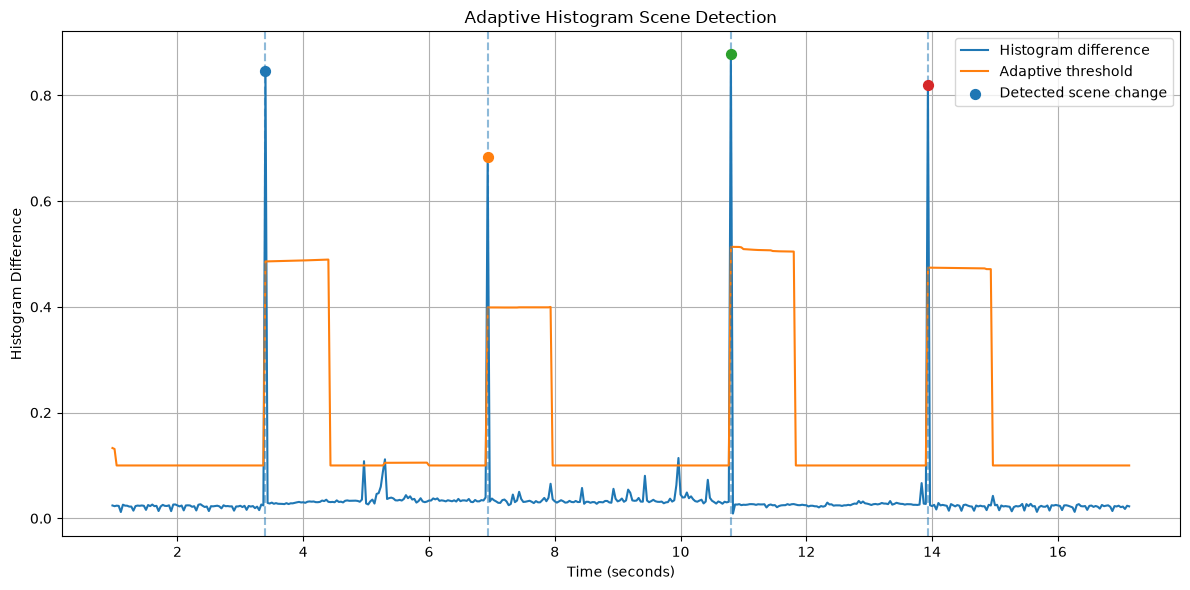

In [3]:
from functions import adaptive_histogram

input_path = ".\\static_videos\\static4.mp4"

# FPS videa
cap = cv2.VideoCapture(input_path)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

scene_changes, all_hist_diffs, thresholds, frame_indices = adaptive_histogram(input_path, window_size=30, threshold_factor=3.0, min_hist_diff=0.1, peak_multiplier=2.0, min_peak_diff=0.5)
time_indices = [frame / fps for frame in frame_indices]

plt.figure(figsize=(12, 6))
plt.plot(time_indices, all_hist_diffs, label="Histogram difference")
plt.plot(time_indices, thresholds, label="Adaptive threshold")

# Scene changes
for i, (frame, diff) in enumerate(scene_changes):

    time = frame / fps
    plt.scatter(time, diff, s=50, zorder=5, label="Detected scene change" if i == 0 else None)
    plt.axvline( x=time, linestyle="--", alpha=0.5)
    
    print(
        f"Scene change {i+1}: "
        f"frame = {frame}, "
        f"time = {time:.2f} s"
    )
    
plt.title("Adaptive Histogram Scene Detection")
plt.xlabel("Time (seconds)")
plt.ylabel("Histogram Difference")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


#ako je dinamicnija scena da window bude manji 
#da li window treba da bude fixan ili moze da se menja

frame=30, mean_sad=3.46
frame=130, mean_sad=13.52
frame=230, mean_sad=12.28
frame=330, mean_sad=4.78
frame=430, mean_sad=3.24
frame=530, mean_sad=1.22
frame=630, mean_sad=8.19
frame=730, mean_sad=25.29
frame=830, mean_sad=7.67
DETEKTOVANE SCENE
frame = 97    time = 3.23 s    combined = 0.587
frame = 116   time = 3.87 s    combined = 0.933
frame = 207   time = 6.90 s    combined = 0.778
frame = 331   time = 11.03 s    combined = 0.865
frame = 495   time = 16.50 s    combined = 0.935
frame = 627   time = 20.90 s    combined = 0.947
frame = 729   time = 24.30 s    combined = 0.819


TEŽINE
Prosečna wSAD  = 0.203
Prosečna wHist = 0.797


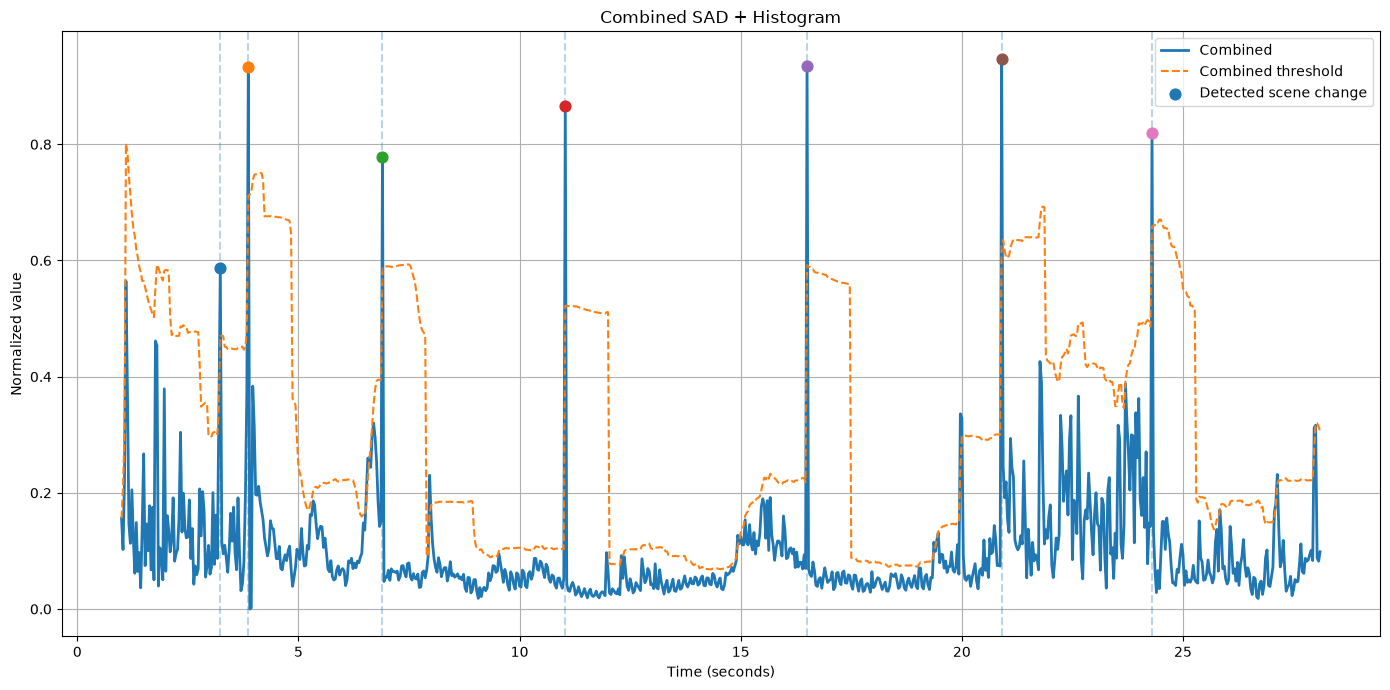

In [1]:
import cv2
import matplotlib.pyplot as plt
from functions import combine_sad_histogram


# ==========================================
# VIDEO
# ==========================================

input_path = ".\\evaluation\\test4.mp4"


# ==========================================
# PARAMETRI
# ==========================================

WINDOW_SIZE = 30

SAD_THRESHOLD_FACTOR = 3.0
MIN_SAD = 5.0
SAD_PEAK_MULTIPLIER = 2.6

HIST_THRESHOLD_FACTOR = 4.0
MIN_HIST_DIFF = 0.05
HIST_PEAK_MULTIPLIER = 1.5
MIN_PEAK_DIFF = 0.5

SAD_LOW_THRESHOLD = 20.0
SAD_HIGH_THRESHOLD = 45.0


# ==========================================
# POKRENI COMBINED
# ==========================================

(
    scene_changes,
    sad,
    hist,
    combined,
    combined_thresholds,
    common_frames,
    weights_sad,
    weights_hist
) = combine_sad_histogram(
    input_path,

    window_size=WINDOW_SIZE,

    sad_threshold_factor=SAD_THRESHOLD_FACTOR,
    min_sad=MIN_SAD,
    sad_peak_multiplier=SAD_PEAK_MULTIPLIER,

    hist_threshold_factor=HIST_THRESHOLD_FACTOR,
    min_hist_diff=MIN_HIST_DIFF,
    hist_peak_multiplier=HIST_PEAK_MULTIPLIER,
    min_peak_diff=MIN_PEAK_DIFF,

    sad_low_threshold=SAD_LOW_THRESHOLD,
    sad_high_threshold=SAD_HIGH_THRESHOLD
)


# ==========================================
# FPS
# ==========================================

cap = cv2.VideoCapture(input_path)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()


# ==========================================
# VREME
# ==========================================

times = [frame / fps for frame in common_frames]


# ==========================================
# DETEKTOVANE SCENE
# ==========================================

print("=" * 70)
print("DETEKTOVANE SCENE")
print("=" * 70)

for frame, value in scene_changes:

    time = frame / fps

    print(
        f"frame = {frame:<5} "
        f"time = {time:.2f} s    "
        f"combined = {value:.3f}"
    )


# ==========================================
# TEŽINE
# ==========================================

print("\n")
print("=" * 70)
print("TEŽINE")
print("=" * 70)

print(f"Prosečna wSAD  = {weights_sad.mean():.3f}")
print(f"Prosečna wHist = {weights_hist.mean():.3f}")


# ==========================================
# GRAFIK
# ==========================================

plt.figure(figsize=(14, 7))


'''
plt.plot(
    times,
    sad,
    label="SAD",
    alpha=0.7
)

plt.plot(
    times,
    hist,
    label="Histogram",
    alpha=0.7
)
'''
plt.plot(
    times,
    combined,
    label="Combined",
    linewidth=2
)

plt.plot(
    times,
    combined_thresholds,
    label="Combined threshold",
    linestyle="--"
)


# ==========================================
# DETEKTOVANE SCENE
# ==========================================

for i, (frame, value) in enumerate(scene_changes):

    time = frame / fps

    plt.scatter(
        time,
        value,
        s=60,
        zorder=5,
        label="Detected scene change"
        if i == 0 else None
    )

    plt.axvline(
        x=time,
        linestyle="--",
        alpha=0.3
    )


plt.title("Combined SAD + Histogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized value")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()